In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/df_empalmado.csv')
df

,Unnamed: 0,Indice_Empalmado
0,1990-01-01,0.248207
1,1990-02-01,0.401422
2,1990-03-01,0.785479
3,1990-04-01,0.875365
4,1990-05-01,0.993851
...,...,...
419,2024-12-01,7694.007500
420,2025-01-01,7864.125700
421,2025-02-01,8052.992700
422,2025-03-01,8353.315800


In [ ]:
df.dtypes

,0
Unnamed: 0,object
Indice_Empalmado,float64


# Tasa de interés a 30 días de plazo fijos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/Tasa Interes depósitos a 30 días - Tasas de interés por depósitos a 30 días de plazo en entidades financieras (en % n.a.).csv")

In [ ]:
df

,Fecha,Tasa Interes depósitos a 30 días
0,04/01/1990,0
1,05/01/1990,0
2,08/01/1990,0
3,09/01/1990,0
4,10/01/1990,0
...,...,...
8391,28/05/2025,"31,39"
8392,29/05/2025,"32,43"
8393,30/05/2025,"31,29"
8394,02/06/2025,"32,75"


In [ ]:
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')

# Paso 2: Crea una columna 'Año_Mes' para agrupar
df['Año_Mes'] = df['Fecha'].dt.to_period('M')
df["Tasa Interes depósitos a 30 días"] = df["Tasa Interes depósitos a 30 días"].astype(str)
df["Tasa Interes depósitos a 30 días"] = df["Tasa Interes depósitos a 30 días"].str.replace(',', '.', regex=False)
df["Tasa Interes depósitos a 30 días"] = df["Tasa Interes depósitos a 30 días"].astype(float)

df.dtypes

,0
Fecha,datetime64[ns]
Tasa Interes depósitos a 30 días,float64
Año_Mes,period[M]


In [ ]:
tasa_interes_promedio_mensual = df.groupby('Año_Mes')['Tasa Interes depósitos a 30 días'].mean()
tasa_interes_promedio_mensual.to_csv("tasa_interes_promedio_mensual.csv",encoding='utf-8')

# Tipo de cambio

In [ ]:
# Cargar el nuevo dataset para Tipo de Cambio
df_tipo_cambio = pd.read_csv("/content/Tipo de cambio PESO-USD.csv")

# Convertir la columna de fecha a tipo datetime
df_tipo_cambio['Fecha'] = pd.to_datetime(df_tipo_cambio['Fecha'], format='%d-%m-%y')
df_tipo_cambio['Año_Mes'] = df_tipo_cambio['Fecha'].dt.to_period('M')

# Convertir la columna del tipo de cambio a tipo float (ajusta el nombre de la columna si es diferente)
# Asegúrate de que el nombre de la columna con los valores del tipo de cambio sea correcto
# Si hay comas como separador decimal, ajústalo.
df_tipo_cambio['Tipo de Cambio de Referencia - en Pesos - por Dólar'] = df_tipo_cambio['Tipo de Cambio de Referencia - en Pesos - por Dólar'].astype(str).str.replace(',', '.', regex=False)
df_tipo_cambio['Tipo de Cambio de Referencia - en Pesos - por Dólar'] = df_tipo_cambio['Tipo de Cambio de Referencia - en Pesos - por Dólar'].astype(float)

# Calcular el promedio mensual del tipo de cambio
# Asegúrate de que el nombre de la columna con los valores del tipo de cambio sea correcto
promedio_mensual_tipo_cambio = df_tipo_cambio.groupby('Año_Mes')['Tipo de Cambio de Referencia - en Pesos - por Dólar'].mean()

# Mostrar resultados
print("Promedio mensual del tipo de cambio Peso-USD:")
print(promedio_mensual_tipo_cambio)

# Guardar el resultado en un archivo CSV
promedio_mensual_tipo_cambio.to_csv('tipo_cambio_peso_usd_mensual.csv', encoding='utf-8')

Promedio mensual del tipo de cambio Peso-USD:
Año_Mes
2002-03       2.398856
2002-04       2.855106
2002-05       3.328700
2002-06       3.621300
2002-07       3.607136
              ...     
2025-02    1058.462500
2025-03    1069.034722
2025-04    1121.567984
2025-05    1147.529160
2025-06    1183.166667
Freq: M, Name: Tipo de Cambio de Referencia - en Pesos - por Dólar, Length: 280, dtype: float64


In [ ]:
df_nivel_general = pd.read_csv("/content/df_empalmado.csv")

nuevos_nombres = {
    'Unnamed: 0': 'fecha',
    'Indice_Empalmado': 'ipc_nivel_general'
}

df_nivel_general = df_nivel_general.rename(columns=nuevos_nombres)

df_nivel_general["fecha"] = pd.to_datetime(df_nivel_general["fecha"])
df_nivel_general['fecha'] = df_nivel_general['fecha'].dt.strftime('%m-%Y')

df_variacion_mensual_ipc = df_nivel_general['variacion_mensual'] = df_nivel_general['ipc_nivel_general'].pct_change()
df_variacion_mensual_ipc

df_nivel_general.to_csv('ipc.csv', encoding='utf-8', index=False)

In [ ]:
df

,Fecha,Tasa Interes depósitos a 30 días,Mes_Año,Año_mes,Año_Mes
0,1990-01-04,0.000000e+00,1990-01,1990-01,1990-01
1,1990-01-05,0.000000e+00,1990-01,1990-01,1990-01
2,1990-01-08,0.000000e+00,1990-01,1990-01,1990-01
3,1990-01-09,0.000000e+00,1990-01,1990-01,1990-01
4,1990-01-10,0.000000e+00,1990-01,1990-01,1990-01
...,...,...,...,...,...
8391,2025-05-28,3.139000e+16,2025-05,2025-05,2025-05
8392,2025-05-29,3.243000e+16,2025-05,2025-05,2025-05
8393,2025-05-30,3.129000e+16,2025-05,2025-05,2025-05
8394,2025-06-02,3.275000e+16,2025-06,2025-06,2025-06


# Precios Commodities


In [ ]:
df_commodities = pd.read_csv("/content/indices_commodities.csv")

In [ ]:
df_commodities['fecha'] = pd.to_datetime(df_commodities['fecha'], format='%b %Y')
df_commodities['fecha'] = df_commodities['fecha'].dt.strftime('%m-%Y')

In [ ]:
df_commodities.to_csv("precios_commodities.csv",encoding='utf-8',index=False)

In [ ]:
df_variaciones_commodities = pd.read_csv("/content/commodities_var_mensual.csv")

In [ ]:
df_variaciones_commodities['fecha'] = pd.to_datetime(df_variaciones_commodities['fecha'], format='%b %Y')
df_variaciones_commodities['fecha'] = df_variaciones_commodities['fecha'].dt.strftime('%m-%Y')

In [ ]:
df_variaciones_commodities.to_csv("variaciones_commodities.csv",encoding='utf-8',index=False)

#Inflacion USA

In [ ]:
df_inflacion_usa = pd.read_csv("/content/infla_usa_listo.csv")
df_inflacion_usa

df_inflacion_usa = df_inflacion_usa.rename(columns={'Fecha': 'fecha',
    "CPIAUCSL" : "ipc_usa", "Variacion_Mensual_CPIAUCSL": "variacion_ipc_usa"})

df_inflacion_usa

,fecha,ipc_usa,variacion_ipc_usa
0,1990-01-01,127.500,NaN
1,1990-02-01,128.000,0.392157
2,1990-03-01,128.600,0.468750
3,1990-04-01,128.900,0.233281
4,1990-05-01,129.100,0.155159
...,...,...,...
419,2024-12-01,317.603,0.364672
420,2025-01-01,319.086,0.466935
421,2025-02-01,319.775,0.215929
422,2025-03-01,319.615,-0.050035


In [ ]:
df_inflacion_usa['fecha'] = pd.to_datetime(df_inflacion_usa['fecha'], format='%Y-%m-%d')
df_inflacion_usa['fecha'] = df_inflacion_usa['fecha'].dt.strftime('%m-%Y')

df_inflacion_usa

,fecha,ipc_usa,variacion_ipc_usa
0,01-1990,127.500,NaN
1,02-1990,128.000,0.392157
2,03-1990,128.600,0.468750
3,04-1990,128.900,0.233281
4,05-1990,129.100,0.155159
...,...,...,...
419,12-2024,317.603,0.364672
420,01-2025,319.086,0.466935
421,02-2025,319.775,0.215929
422,03-2025,319.615,-0.050035


In [ ]:
df_inflacion_usa.to_csv("inflacion_usa.csv",encoding='utf-8',index=False)

# Base Monetaria

In [ ]:
df_base_monetaria = pd.read_csv("/content/base_monetaria.csv")
df_base_monetaria

,fecha,base_monetaria
0,02/01/1996,13.069
1,03/01/1996,12.970
2,04/01/1996,13.034
3,05/01/1996,13.097
4,08/01/1996,13.104
...,...,...
7245,29/05/2025,33.286.265
7246,30/05/2025,34.940.118
7247,02/06/2025,36.927.413
7248,03/06/2025,36.423.142


In [ ]:
df_base_monetaria['fecha'] = pd.to_datetime(df_base_monetaria['fecha'], format='%d/%m/%Y')


df_base_monetaria

,fecha,base_monetaria
0,1996-01-02,13.069
1,1996-01-03,12.970
2,1996-01-04,13.034
3,1996-01-05,13.097
4,1996-01-08,13.104
...,...,...
7245,2025-05-29,33.286.265
7246,2025-05-30,34.940.118
7247,2025-06-02,36.927.413
7248,2025-06-03,36.423.142


In [ ]:
df_base_monetaria = df_base_monetaria.groupby(df_base_monetaria['fecha'].dt.to_period('M')).tail(1) #Vamos a quedarnos con el último dato de cada mes
df_base_monetaria['fecha'] = df_base_monetaria['fecha'].dt.strftime('%m-%Y')

<ipython-input-92-603b05406b96>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_base_monetaria['fecha'] = df_base_monetaria['fecha'].dt.strftime('%m-%Y')


,fecha,base_monetaria
21,01-1996,12.209
42,02-1996,12.094
63,03-1996,11.960
83,04-1996,12.043
105,05-1996,12.185
...,...,...
7189,02-2025,30.282.166
7207,03-2025,30.534.180
7226,04-2025,32.698.982
7246,05-2025,34.940.118


In [ ]:
df_base_monetaria.to_csv("base_monetaria.csv",encoding='utf-8',index=False)

# REM

Inflación esperada - REM próximos 12 meses - MEDIANA (variación en i.a)

In [ ]:
df_expectativas = pd.read_csv("/content/Expectativas Inflación.csv")
df_expectativas

,fecha,expectativas_infla
0,31/01/2004,"7,5"
1,29/02/2004,7
2,31/03/2004,"7,1"
3,30/04/2004,"7,4"
4,31/05/2004,"7,6"
...,...,...
207,31/01/2025,"21,9"
208,28/02/2025,"22,2"
209,31/03/2025,"24,5"
210,30/04/2025,"26,3"


In [ ]:
df_expectativas['fecha'] = pd.to_datetime(df_expectativas['fecha'], format='%d/%m/%Y')
df_expectativas['fecha'] = df_expectativas['fecha'].dt.strftime('%m-%Y')

df_expectativas['expectativas_infla'] = df_expectativas['expectativas_infla'].astype(str).str.replace(',', '.', regex=False)
df_expectativas['expectativas_infla'] = df_expectativas['expectativas_infla'].astype(float)

df_expectativas

,fecha,expectativas_infla
0,01-2004,7.5
1,02-2004,7.0
2,03-2004,7.1
3,04-2004,7.4
4,05-2004,7.6
...,...,...
207,01-2025,21.9
208,02-2025,22.2
209,03-2025,24.5
210,04-2025,26.3


Ahora debemos de calcular su respectiva variación para cada mes

In [ ]:
df_expectativas['variacion_mensual_rem'] = df_expectativas['expectativas_infla'].pct_change()
df_expectativas

,fecha,expectativas_infla,variacion_mensual_rem
0,01-2004,7.5,NaN
1,02-2004,7.0,-0.066667
2,03-2004,7.1,0.014286
3,04-2004,7.4,0.042254
4,05-2004,7.6,0.027027
...,...,...,...
207,01-2025,21.9,-0.154440
208,02-2025,22.2,0.013699
209,03-2025,24.5,0.103604
210,04-2025,26.3,0.073469


In [ ]:
df_expectativas.to_csv("expectativas_infla.csv",encoding='utf-8',index=False)

# M2

M2 privado, promedio móvil de 30 días, variación interanual

In [ ]:
df_m2 = pd.read_csv("M2.csv")
df_m2

,fecha,m2_variacion_interanual
0,31/01/2004,"53,3"
1,01/02/2004,"53,3"
2,02/02/2004,"53,5"
3,03/02/2004,"53,7"
4,04/02/2004,"53,9"
...,...,...
7798,07/06/2025,"20,7"
7799,08/06/2025,"20,4"
7800,09/06/2025,"19,9"
7801,10/06/2025,"19,3"


In [ ]:
df_m2['fecha'] = pd.to_datetime(df_m2['fecha'], format='%d/%m/%Y')

df_m2 = df_m2.groupby(df_m2['fecha'].dt.to_period('M')).tail(1) # Me quedo únicamente con los últimos datos para cada mes
df_m2

,fecha,m2_variacion_interanual
0,2004-01-31,"53,3"
29,2004-02-29,"58,5"
60,2004-03-31,"60,3"
90,2004-04-30,"64,1"
121,2004-05-31,59
...,...,...
7699,2025-02-28,"69,4"
7730,2025-03-31,"22,9"
7760,2025-04-30,"33,7"
7791,2025-05-31,"23,4"


In [ ]:
df_m2['fecha'] = df_m2['fecha'].dt.strftime('%m-%Y')

df_m2['m2_variacion_interanual'] = df_m2['m2_variacion_interanual'].astype(str).str.replace(',', '.', regex=False)
df_m2['m2_variacion_interanual'] = df_m2['m2_variacion_interanual'].astype(float)

df_m2

<ipython-input-20-770176130>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_m2['fecha'] = df_m2['fecha'].dt.strftime('%m-%Y')
<ipython-input-20-770176130>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_m2['m2_variacion_interanual'] = df_m2['m2_variacion_interanual'].astype(str).str.replace(',', '.', regex=False)
<ipython-input-20-770176130>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the

,fecha,m2_variacion_interanual
0,01-2004,53.3
29,02-2004,58.5
60,03-2004,60.3
90,04-2004,64.1
121,05-2004,59.0
...,...,...
7699,02-2025,69.4
7730,03-2025,22.9
7760,04-2025,33.7
7791,05-2025,23.4


Calculando su variación entre meses

In [ ]:
df_agregados_monetarios = pd.read_csv("/content/agregados-monetarios.csv")
df_agregados_monetarios

,indice_tiempo,base_monetaria_total,base_monetaria_circulacion_monetaria_total,base_monetaria_circulacion_monetaria_publico,base_monetaria_circulacion_monetaria_ent_financieras,base_monetaria_cuenta_corriente_bcra,depositos_cuenta_corriente_total,depositos_cuenta_corriente_privado,depositos_cuenta_corriente_publico,depositos_caja_ahorro_total,...,det_desagreg_plazo_fijo_sec_priv_usd_180_365_dias,det_desagreg_plazo_fijo_sec_priv_usd_366_mas,det_desagreg_plazo_fijo_sec_priv_total,det_desagreg_plazo_fijo_sec_priv_pesos_usd_mayoristas,det_desagreg_plazo_fijo_sec_priv_pesos_usd_minoristas,det_desagreg_plazo_fijo_sec_priv_pesos_usd_hasta_59_dias,det_desagreg_plazo_fijo_sec_priv_pesos_usd_60_89_dias,det_desagreg_plazo_fijo_sec_priv_pesos_usd_90_179_dias,det_desagreg_plazo_fijo_sec_priv_pesos_usd_180_365_dias,det_desagreg_plazo_fijo_sec_priv_pesos_usd_366_mas
0,2003-01-01,3.740912e+04,1.875467e+04,1.639825e+04,2356.419355,1.084045e+04,2838.870968,1.111190e+04,1.395077e+04,677.935484,...,35.354839,10.290323,33680.387865,6441.252819,27239.135045,16461.836829,2602.114739,875.978919,482.746713,13255.820026
1,2003-02-01,3.723437e+04,1.881771e+04,1.654096e+04,2276.750000,1.060265e+04,2452.964286,1.077514e+04,1.322811e+04,673.000000,...,34.464286,14.000000,35281.077786,7057.046339,28224.031446,17945.101261,3046.792479,1100.569143,476.801832,12711.179779
2,2003-03-01,3.808015e+04,1.928015e+04,1.701722e+04,2262.935484,1.110793e+04,2900.516129,1.059932e+04,1.349984e+04,617.870968,...,31.548387,14.000000,35974.135248,7322.161126,28651.974123,19519.279413,3036.423448,1217.039687,462.442958,11737.908658
3,2003-04-01,3.854499e+04,1.994740e+04,1.755490e+04,2392.500000,1.092358e+04,2771.233333,1.039803e+04,1.316927e+04,599.366667,...,31.133333,14.466667,36854.444127,7778.277350,29076.166777,21238.381167,3184.359593,2547.289407,507.039300,9377.444313
4,2003-05-01,4.058468e+04,2.042510e+04,1.806704e+04,2358.064516,1.268007e+04,3671.612903,1.070316e+04,1.437477e+04,789.193548,...,30.032258,14.967742,38231.099494,8540.117429,29690.982065,22815.019219,3506.666558,5027.619465,584.211345,6298.530081
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263,2024-12-01,3.394480e+06,2.504730e+06,2.230702e+06,274028.516129,8.897494e+05,690070.607143,1.972196e+06,2.662266e+06,77912.392857,...,0.762226,0.035548,33795.387528,30400.778494,3394.609035,28892.532380,1880.197883,1767.774499,1205.279535,49.967143
264,2025-01-01,3.685633e+06,2.677121e+06,2.412204e+06,264917.322581,1.008512e+06,742996.064516,1.996895e+06,2.739891e+06,76109.612903,...,0.834032,0.035258,32870.771262,29359.096797,3511.674465,27632.117860,1854.790949,1924.691024,1406.824276,52.347043
265,2025-02-01,3.750943e+06,2.686579e+06,2.417014e+06,269564.321429,1.064364e+06,716023.700000,2.061350e+06,2.777374e+06,81708.600000,...,0.869143,0.035393,36878.906157,33160.982194,3717.923963,31463.630639,1871.809227,2007.431217,1481.858096,54.025835
266,2025-03-01,3.660266e+06,2.674269e+06,2.392919e+06,281350.516129,9.859970e+05,720821.000000,2.221643e+06,2.942464e+06,94522.258065,...,0.879935,0.039323,39776.519988,35930.470653,3846.049335,34230.197672,2048.133903,1945.031687,1493.283944,59.803819


In [ ]:
df_agregados_monetarios = df_agregados_monetarios.rename(columns={'indice_tiempo': 'fecha'})

df_m2 = df_agregados_monetarios[["fecha", "agregados_monetarios_totales_m2_privado"]]


df_m2['fecha'] = pd.to_datetime(df_m2['fecha'], format='%Y-%m-%d')
df_m2['fecha'] = df_m2['fecha'].dt.strftime('%m-%Y')
df_m2

<ipython-input-31-3811715703>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_m2['fecha'] = pd.to_datetime(df_m2['fecha'], format='%Y-%m-%d')
<ipython-input-31-3811715703>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_m2['fecha'] = df_m2['fecha'].dt.strftime('%m-%Y')


,fecha,agregados_monetarios_totales_m2_privado
0,01-2003,3.582502e+04
1,02-2003,3.552471e+04
2,03-2003,3.568532e+04
3,04-2003,3.587874e+04
4,05-2003,3.696304e+04
...,...,...
263,12-2024,2.030699e+07
264,01-2025,2.204353e+07
265,02-2025,2.239761e+07
266,03-2025,2.316339e+07


In [ ]:
df_m2['m2_var_men'] = df_m2['agregados_monetarios_totales_m2_privado'].pct_change()
df_m2

<ipython-input-34-2837724832>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_m2['m2_var_men'] = df_m2['agregados_monetarios_totales_m2_privado'].pct_change()


,fecha,agregados_monetarios_totales_m2_privado,m2_var_men
0,01-2003,3.582502e+04,NaN
1,02-2003,3.552471e+04,-0.008383
2,03-2003,3.568532e+04,0.004521
3,04-2003,3.587874e+04,0.005420
4,05-2003,3.696304e+04,0.030221
...,...,...,...
263,12-2024,2.030699e+07,0.105974
264,01-2025,2.204353e+07,0.085515
265,02-2025,2.239761e+07,0.016063
266,03-2025,2.316339e+07,0.034190


In [ ]:
df_m2.to_csv("m2.csv",encoding='utf-8',index=False)

# Expectativa de Inflación


In [ ]:
df_rem_bcra = pd.read_csv("/content/rem_04-25_sin_duplicados.csv")
df_rem_bcra

,fecha,rem
0,2004-01,0.00000
1,2004-02,0.45517
2,2004-03,0.49643
3,2004-04,0.51212
4,2004-05,0.52759
...,...,...
253,2025-02,2.10000
254,2025-03,2.10000
255,2025-04,2.30000
256,2025-05,2.80000


In [ ]:
df_eei_dit = pd.read_csv("/content/Encuesta de Expectativas de Inflación - Di Tella.csv")

df_eei_dit['eei'] = df_eei_dit['eei'].astype(str).str.replace(',', '.', regex=False)
df_eei_dit['eei'] = df_eei_dit['eei'].astype(float)

df_eei_dit

,fecha,eei
0,2006-08,1.075688
1,2006-09,0.941365
2,2006-10,0.926318
3,2006-11,1.001307
4,2006-12,1.090492
...,...,...
222,2025-02,2.941053
223,2025-03,2.874174
224,2025-04,2.922860
225,2025-05,2.769866


In [ ]:
df = pd.read_csv("/content/DATASET.csv")
df_ipc = df[["fecha","ipc_var_mensual"]]

df_ipc

,fecha,ipc_var_mensual
0,2004-02,0.087719
1,2004-03,0.598890
2,2004-04,0.856687
3,2004-05,0.604665
4,2004-06,0.686892
...,...,...
250,2024-12,2.704104
251,2025-01,2.211048
252,2025-02,2.401627
253,2025-03,3.729335


In [ ]:
df_merged = pd.merge(df_eei_dit, df_rem_bcra, on='fecha', how='inner')
df_merged

,fecha,eei,rem
0,2006-08,1.075688,0.63214
1,2006-09,0.941365,0.77586
2,2006-10,0.926318,0.74286
3,2006-11,1.001307,0.75000
4,2006-12,1.090492,0.92000
...,...,...,...
222,2025-02,2.941053,2.10000
223,2025-03,2.874174,2.10000
224,2025-04,2.922860,2.30000
225,2025-05,2.769866,2.80000


In [ ]:
df_merged = pd.merge(df_merged, df_ipc, on='fecha', how='inner')
df_merged

,fecha,eei,rem,ipc_var_mensual
0,2006-08,1.075688,0.63214,0.560289
1,2006-09,0.941365,0.77586,0.905398
2,2006-10,0.926318,0.74286,0.701714
3,2006-11,1.001307,0.75000,0.993831
4,2006-12,1.090492,0.92000,1.606153
...,...,...,...,...
220,2024-12,3.144799,2.90000,2.704104
221,2025-01,2.916788,2.50000,2.211048
222,2025-02,2.941053,2.10000,2.401627
223,2025-03,2.874174,2.10000,3.729335


In [ ]:
df_merged['fecha'] = pd.to_datetime(df_merged['fecha'], format='%Y-%m')
print(df_merged.dtypes)

fecha               datetime64[ns]
eei                        float64
rem                        float64
ipc_var_mensual            float64
promedio_eei_rem           float64
dtype: object


Primeras filas de df_merged:
       fecha       eei      rem  ipc_var_mensual  promedio_eei_rem
0 2006-08-01  1.075688  0.63214         0.560289          0.853914
1 2006-09-01  0.941365  0.77586         0.905398          0.858613
2 2006-10-01  0.926318  0.74286         0.701714          0.834589
3 2006-11-01  1.001307  0.75000         0.993831          0.875653
4 2006-12-01  1.090492  0.92000         1.606153          1.005246

Tipos de datos de df_merged:
fecha               datetime64[ns]
eei                        float64
rem                        float64
ipc_var_mensual            float64
promedio_eei_rem           float64
dtype: object


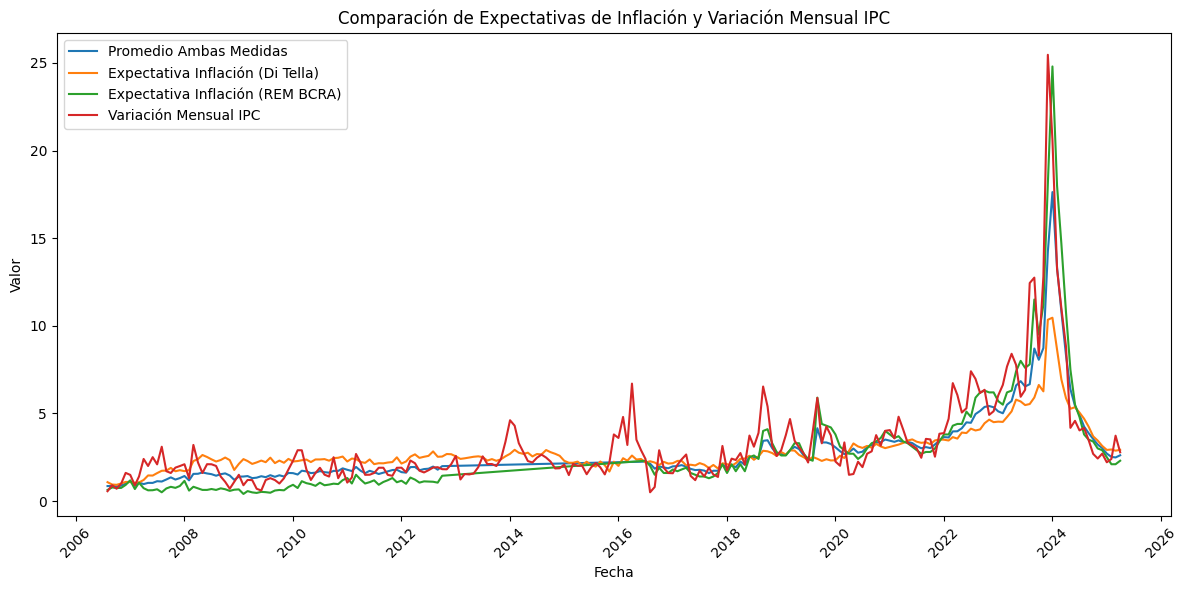

In [ ]:
# Paso 2: Visualizar las primeras filas y tipos de datos
print("Primeras filas de df_merged:")
print(df_merged.head())
print("\nTipos de datos de df_merged:")
print(df_merged.dtypes)

# Paso 3: Crear un gráfico de línea para comparar las series de tiempo
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_merged, x='fecha', y='eei', label='Expectativa Inflación (Di Tella)')
sns.lineplot(data=df_merged, x='fecha', y='rem', label='Expectativa Inflación (REM BCRA)')
sns.lineplot(data=df_merged, x='fecha', y='ipc_var_mensual', label='Variación Mensual IPC')

plt.title('Comparación de Expectativas de Inflación y Variación Mensual IPC')
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

#Base de datos

 https://www.datos.gob.ar/series/api/series/?ids=90.1_AMTM2_0_0_31&representation_mode=percent_change

# Merge y armado final

Para realizar el correspondiente análisis, vamos a realizar un merge entre todas las distintas bases de datos con las que trabajamos

# Reorganización dataset

In [ ]:
df = pd.read_csv("/content/DATASET.csv")
df

,fecha,emae_varm_b2004,brecha,Varm_ccl_unificado,Varm_ccl_implicito,BM_varm,BM_varm_lag_1,BM_varm_lag_2,tasa_i_promedio,ipc_var_mensual,...,tcr_bra_varm,tcr_dolar_varm,tcn_of_varm,REM_varm%,REM_varmpp,M2_varm,M2_varm_lag_1,M2_varm_lag_2,M2_varm_lag_3,M2_varm_lag_4
0,2004-02,-0.274415,-4.499441,0.446602,0.446602,-0.217049,1.299821,5.059221,2.310500,0.087719,...,-1.1,1.2,1.350821,-6.666667,-0.5,2.666012,3.424125,6.965713,3.866262,0.798322
1,2004-03,-0.434358,-9.669992,-6.522468,-6.522468,-2.684893,-0.217049,1.299821,2.384348,0.598890,...,-0.1,-1.3,-1.171750,1.428571,0.1,1.506627,2.666012,3.424125,6.965713,3.866262
2,2004-04,-2.411566,-3.066653,5.027076,5.027076,3.138080,-2.684893,-0.217049,2.139474,0.856687,...,-2.5,-2.8,-2.127629,4.225352,0.3,2.943459,1.506627,2.666012,3.424125,6.965713
3,2004-05,1.326239,1.595288,7.904991,7.904991,1.242962,3.138080,-2.684893,2.454000,0.604665,...,-3.5,2.6,2.953515,2.702703,0.2,-0.033009,2.943459,1.506627,2.666012,3.424125
4,2004-06,1.927382,3.005998,2.797813,2.797813,2.050367,1.242962,3.138080,2.489524,0.686892,...,0.2,1.1,1.389954,-1.315789,-0.1,1.583698,-0.033009,2.943459,1.506627,2.666012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250,2024-12,1.204659,15.826551,6.936411,7.266766,24.784607,4.880464,1.425429,32.230526,2.704104,...,-4.7,-0.2,1.883382,-11.904762,-3.5,10.597367,3.524611,5.520347,3.209878,4.913793
251,2025-01,0.522754,14.740578,-0.128061,1.280873,1.742505,24.784607,4.880464,30.764091,2.211048,...,1.1,0.0,2.239455,-15.444015,-4.0,8.551476,10.597367,3.524611,5.520347,3.209878
252,2025-02,0.741268,13.505582,2.916291,0.335913,0.117597,1.742505,24.784607,27.577000,2.401627,...,4.6,-0.5,1.427617,1.369863,0.3,1.606266,8.551476,10.597367,3.524611,5.520347
253,2025-03,-1.765581,21.975078,8.154232,8.535103,0.832219,0.117597,1.742505,28.533889,3.729335,...,-1.1,-1.9,0.998828,10.360360,2.3,3.419029,1.606266,8.551476,10.597367,3.524611


In [ ]:
df.columns

Index(['fecha', 'emae_varm_b2004', 'brecha', 'Varm_ccl_unificado',
       'Varm_ccl_implicito', 'BM_varm', 'BM_varm_lag_1', 'BM_varm_lag_2',
       'tasa_i_promedio', 'ipc_var_mensual', 'inflacion_t-1', 'inflacion_t-2',
       'maiz_var_mensual', 'poroto_var_mensual', 'soja_var_mensual',
       'acetite_var_mensual', 'trigo_var_mensual', 'petroleo_var_mensual',
       'ipc_usa_varm', 'RIPTE_varm', 'RIPTE_varm_lag_1',
       'tcr_multilateral_varm', 'tcr_bra_varm', 'tcr_dolar_varm',
       'tcn_of_varm', 'REM_varm%', 'REM_varmpp', 'M2_varm', 'M2_varm_lag_1',
       'M2_varm_lag_2', 'M2_varm_lag_3', 'M2_varm_lag_4'],
      dtype='object')

In [ ]:
columnas_a_eliminar = ['REM_varm%', 'REM_varmpp']
df = df.drop(columnas_a_eliminar, axis=1)

In [ ]:
nuevo_orden_columnas = ["fecha", 'ipc_var_mensual', 'inflacion_t-1', 'inflacion_t-2','tasa_i_promedio','BM_varm', 'BM_varm_lag_1', 'BM_varm_lag_2','M2_varm', 'M2_varm_lag_1',
       'M2_varm_lag_2', 'M2_varm_lag_3', 'M2_varm_lag_4','emae_varm_b2004','RIPTE_varm', 'RIPTE_varm_lag_1','brecha', 'Varm_ccl_unificado',
       'Varm_ccl_implicito','tcr_multilateral_varm', 'tcr_bra_varm', 'tcr_dolar_varm','ipc_usa_varm','soja_var_mensual',
       'acetite_var_mensual', 'trigo_var_mensual', 'petroleo_var_mensual','maiz_var_mensual']

df = df[nuevo_orden_columnas]
df = df.rename(columns={'acetite_var_mensual': 'aceite_var_mensual'})

In [ ]:
df.to_csv("DATASET_V2.csv",encoding='utf-8',index=False)

In [ ]:
df.dtypes

,0
fecha,object
ipc_var_mensual,float64
inflacion_t-1,float64
inflacion_t-2,float64
tasa_i_promedio,float64
BM_varm,float64
BM_varm_lag_1,float64
BM_varm_lag_2,float64
M2_varm,float64
M2_varm_lag_1,float64


In [ ]:
df_rem = pd.read_csv("/content/REM_M_DUMMY.csv")
df_rem

,fecha,expectativas_infla,var_abs_expectativas,var_pct_expectativas,es_proxy
0,2004-02,7.0,-0.5,-6.666667,0
1,2004-03,7.1,0.1,1.428571,0
2,2004-04,7.4,0.3,4.225352,0
3,2004-05,7.6,0.2,2.702703,0
4,2004-06,7.5,-0.1,-1.315789,0
...,...,...,...,...,...
250,2025-01,21.9,-4.0,-15.444015,0
251,2025-02,22.2,0.3,1.369863,0
252,2025-03,24.5,2.3,10.360360,0
253,2025-04,26.3,1.8,7.346939,0


In [ ]:
df_merged = pd.merge(df, df_rem, on='fecha', how='inner')
df_merged

,fecha,ipc_var_mensual,inflacion_t-1,inflacion_t-2,tasa_i_promedio,BM_varm,BM_varm_lag_1,BM_varm_lag_2,M2_varm,M2_varm_lag_1,...,ipc_usa_varm,soja_var_mensual,aceite_var_mensual,trigo_var_mensual,petroleo_var_mensual,maiz_var_mensual,expectativas_infla,var_abs_expectativas,var_pct_expectativas,es_proxy
0,2004-02,0.087719,0.425782,0.205973,2.310500,-0.217049,1.299821,5.059221,2.666012,3.424125,...,0.214707,0.052021,0.095054,-0.037720,0.016858,0.057523,7.0,-0.5,-6.666667,0
1,2004-03,0.598890,0.087719,0.425782,2.384348,-2.684893,-0.217049,1.299821,1.506627,2.666012,...,0.214247,0.139388,0.047685,0.005749,0.058720,0.044966,7.1,0.1,1.428571,0
2,2004-04,0.856687,0.598890,0.087719,2.139474,3.138080,-2.684893,-0.217049,2.943459,1.506627,...,0.160342,0.007844,-0.025801,0.024666,-0.001136,0.038761,7.4,0.3,4.225352,0
3,2004-05,0.604665,0.856687,0.598890,2.454000,1.242962,3.138080,-2.684893,-0.033009,2.943459,...,0.426894,-0.043008,-0.055279,-0.019721,0.096783,-0.031132,7.6,0.2,2.702703,0
4,2004-06,0.686892,0.604665,0.856687,2.489524,2.050367,1.242962,3.138080,1.583698,-0.033009,...,0.371945,-0.079458,-0.081398,-0.044159,-0.055409,-0.046459,7.5,-0.1,-1.315789,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249,2024-12,2.704104,2.426556,2.691738,32.230526,24.784607,4.880464,1.425429,10.597367,3.524611,...,0.364672,-0.011710,-0.078962,0.000321,0.003015,0.007559,25.9,-3.5,-11.904762,0
250,2025-01,2.211048,2.704104,2.426556,30.764091,1.742505,24.784607,4.880464,8.551476,10.597367,...,0.466935,0.045999,0.070084,0.026025,0.078300,0.056845,21.9,-4.0,-15.444015,0
251,2025-02,2.401627,2.211048,2.704104,27.577000,0.117597,1.742505,24.784607,1.606266,8.551476,...,0.215929,0.011197,0.045497,-0.002765,-0.054250,0.032164,22.2,0.3,1.369863,0
252,2025-03,3.729335,2.401627,2.211048,28.533889,0.832219,0.117597,1.742505,3.419029,1.606266,...,-0.050035,-0.033343,-0.072968,-0.055213,-0.046161,-0.061029,24.5,2.3,10.360360,0


In [ ]:
df_merged.to_csv("DATASET_V3.csv",encoding='utf-8',index=False)

### REM con ruido blanco para período faltante

# Creación de nuevas variables

In [ ]:
df = pd.read_csv("/content/DATASET_V4.csv")
df

,fecha,ipc_var_mensual,expectativas_infla,inflacion_t-1,inflacion_t-2,tasa_i_promedio,BM_varm,BM_varm_lag_1,BM_varm_lag_2,M2_varm,...,Varm_ccl_implicito,tcr_multilateral_varm,tcr_bra_varm,tcr_dolar_varm,ipc_usa_varm,soja_var_mensual,aceite_var_mensual,trigo_var_mensual,petroleo_var_mensual,maiz_var_mensual
0,2004-02,0.087719,0.45517,0.425782,0.205973,2.310500,-0.217049,1.299821,5.059221,2.666012,...,0.446602,0.5,-1.1,1.2,0.214707,0.052021,0.095054,-0.037720,0.016858,0.057523
1,2004-03,0.598890,0.49643,0.087719,0.425782,2.384348,-2.684893,-0.217049,1.299821,1.506627,...,-6.522468,-2.0,-0.1,-1.3,0.214247,0.139388,0.047685,0.005749,0.058720,0.044966
2,2004-04,0.856687,0.51212,0.598890,0.087719,2.139474,3.138080,-2.684893,-0.217049,2.943459,...,5.027076,-3.2,-2.5,-2.8,0.160342,0.007844,-0.025801,0.024666,-0.001136,0.038761
3,2004-05,0.604665,0.52759,0.856687,0.598890,2.454000,1.242962,3.138080,-2.684893,-0.033009,...,7.904991,0.2,-3.5,2.6,0.426894,-0.043008,-0.055279,-0.019721,0.096783,-0.031132
4,2004-06,0.686892,0.59375,0.604665,0.856687,2.489524,2.050367,1.242962,3.138080,1.583698,...,2.797813,1.2,0.2,1.1,0.371945,-0.079458,-0.081398,-0.044159,-0.055409,-0.046459
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249,2024-12,2.704104,2.90000,2.426556,2.691738,32.230526,24.784607,4.880464,1.425429,10.597367,...,7.266766,-2.4,-4.7,-0.2,0.364672,-0.011710,-0.078962,0.000321,0.003015,0.007559
250,2025-01,2.211048,2.50000,2.704104,2.426556,30.764091,1.742505,24.784607,4.880464,8.551476,...,1.280873,-0.1,1.1,0.0,0.466935,0.045999,0.070084,0.026025,0.078300,0.056845
251,2025-02,2.401627,2.10000,2.211048,2.704104,27.577000,0.117597,1.742505,24.784607,1.606266,...,0.335913,1.7,4.6,-0.5,0.215929,0.011197,0.045497,-0.002765,-0.054250,0.032164
252,2025-03,3.729335,2.10000,2.401627,2.211048,28.533889,0.832219,0.117597,1.742505,3.419029,...,8.535103,-0.7,-1.1,-1.9,-0.050035,-0.033343,-0.072968,-0.055213,-0.046161,-0.061029


In [ ]:
df['fecha'] = pd.to_datetime(df['fecha'], format='%Y-%m')

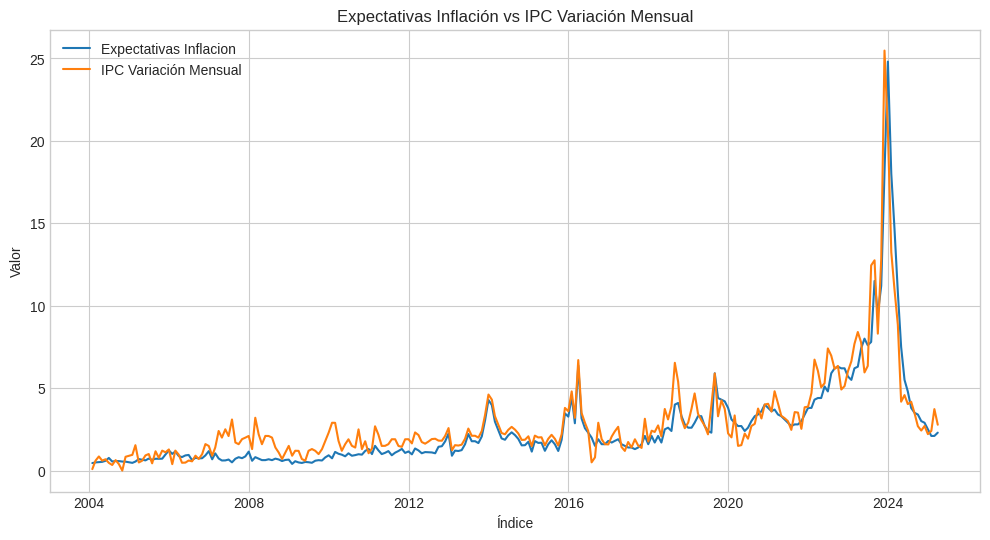

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="fecha", y='expectativas_infla', label='Expectativas Inflacion')
sns.lineplot(data=df, x="fecha", y='ipc_var_mensual', label='IPC Variación Mensual')
plt.title('Expectativas Inflación vs IPC Variación Mensual')
plt.xlabel('Índice')
plt.ylabel('Valor')
plt.legend()
plt.show()

Desde Febrero de 2007 a Septiembre de 2012 hubo una subestimación sistemática por parte de la estadística del BCRA con respecto a la inflación. Directamente para el período entre Octubre de 2012 y Mayo de 2016 no hay información directa del BCRA

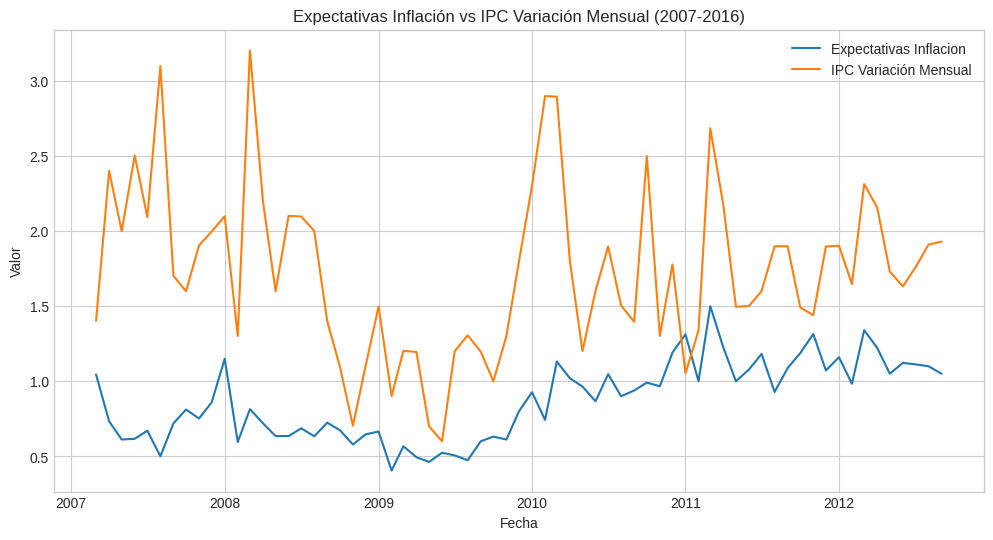

In [ ]:
# Filtrar el DataFrame para el rango de fechas
df_filtrado = df[(df['fecha'] >= '2007-03-01') & (df['fecha'] <= '2012-09-01')]

# Graficar usando el DataFrame filtrado
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_filtrado, x='fecha', y='expectativas_infla', label='Expectativas Inflacion')
sns.lineplot(data=df_filtrado, x='fecha', y='ipc_var_mensual', label='IPC Variación Mensual')
plt.title('Expectativas Inflación vs IPC Variación Mensual (2007-2016)')
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.legend()
plt.show()

In [ ]:
# Defino el rango de fechas para asignarles el valor
fecha_inicio = '2007-03-01'
fecha_fin = '2016-05-01'

# Crea la condición booleana
condicion_fechas = (df['fecha'] >= fecha_inicio) & (df['fecha'] <= fecha_fin)

# Reemplaza los valores en la columna 'expectativas_infla' que cumplen la condición
df.loc[condicion_fechas, 'expectativas_infla'] = -99

### Variables de volatilidad de la inflación

In [ ]:
# Volatilidad móvil de 6 meses
df['volatilidad_6m'] = df['ipc_var_mensual'].rolling(6).std()

# Coeficiente de variación móvil (normalizado por el nivel)
df['cv_6m'] = df['ipc_var_mensual'].rolling(6).std() / df['ipc_var_mensual'].rolling(6).mean()

### Variables político-electorales

In [ ]:
# Años electorales presidenciales
election_years = [2004, 2008, 2012, 2016, 2020, 2024] # Se toma desde el año siguiente a la elección

# Calcular año de mandato (1-4)
def get_mandate_year(date):
    year = date.year
    for election_year in sorted(election_years, reverse=True):
        if year >= election_year:
            return min(year - election_year + 1, 4)
    return 1

df['año_mandato'] = df['fecha'].apply(get_mandate_year)
df['es_año_electoral'] = df['fecha'].dt.year.isin([year - 1 for year in election_years])

### Variables para ver componente estacional

In [ ]:
df['trimestre'] = df['fecha'].dt.quarter

### Últimos retoques

In [ ]:
df = df.dropna()
df

,fecha,ipc_var_mensual,expectativas_infla,inflacion_t-1,inflacion_t-2,tasa_i_promedio,BM_varm,BM_varm_lag_1,BM_varm_lag_2,M2_varm,...,soja_var_mensual,aceite_var_mensual,trigo_var_mensual,petroleo_var_mensual,maiz_var_mensual,volatilidad_6m,cv_6m,año_mandato,es_año_electoral,trimestre
5,2004-07-01,0.469016,0.76667,0.686892,0.604665,2.513810,-3.218377,2.050367,1.242962,3.025927,...,-0.095070,-0.077538,-0.032690,0.069494,-0.152372,0.260167,0.472477,1,False,3
6,2004-08-01,0.339511,0.54848,0.469016,0.686892,2.847619,0.733076,-3.218377,2.050367,0.025165,...,-0.220837,-0.096827,-0.078041,0.104483,-0.003841,0.177845,0.300105,1,False,3
7,2004-09-01,0.634428,0.58056,0.339511,0.469016,2.990455,0.267893,0.733076,-3.218377,0.341595,...,-0.085668,-0.021497,0.039039,0.020585,-0.061159,0.178686,0.298540,1,False,3
8,2004-10-01,0.392267,0.57500,0.634428,0.339511,3.026500,-3.456473,0.267893,0.733076,0.453109,...,-0.063035,-0.099907,-0.029683,0.159313,-0.044120,0.141137,0.270829,1,False,4
9,2004-11-01,0.000000,0.54688,0.392267,0.634428,3.023182,6.066549,-3.456473,0.267893,0.874522,...,0.012324,0.006280,0.033130,-0.087175,0.003676,0.246276,0.585881,1,False,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249,2024-12-01,2.704104,2.90000,2.426556,2.691738,32.230526,24.784607,4.880464,1.425429,10.597367,...,-0.011710,-0.078962,0.000321,0.003015,0.007559,0.747825,0.230161,1,False,4
250,2025-01-01,2.211048,2.50000,2.704104,2.426556,30.764091,1.742505,24.784607,4.880464,8.551476,...,0.045999,0.070084,0.026025,0.078300,0.056845,0.736292,0.249945,2,False,1
251,2025-02-01,2.401627,2.10000,2.211048,2.704104,27.577000,0.117597,1.742505,24.784607,1.606266,...,0.011197,0.045497,-0.002765,-0.054250,0.032164,0.442733,0.167024,2,False,1
252,2025-03-01,3.729335,2.10000,2.401627,2.211048,28.533889,0.832219,0.117597,1.742505,3.419029,...,-0.033343,-0.072968,-0.055213,-0.046161,-0.061029,0.540791,0.200734,2,False,1


In [ ]:
df.to_csv("DATASET_V5.csv", index=False)

In [ ]:
df = pd.read_csv("DATASET_V3.csv")
df

,fecha,ipc_var_mensual,inflacion_t-1,inflacion_t-2,tasa_i_promedio,BM_varm,BM_varm_lag_1,BM_varm_lag_2,M2_varm,M2_varm_lag_1,...,ipc_usa_varm,soja_var_mensual,aceite_var_mensual,trigo_var_mensual,petroleo_var_mensual,maiz_var_mensual,expectativas_infla,var_abs_expectativas,var_pct_expectativas,es_proxy
0,2004-02,0.087719,0.425782,0.205973,2.310500,-0.217049,1.299821,5.059221,2.666012,3.424125,...,0.214707,0.052021,0.095054,-0.037720,0.016858,0.057523,7.0,-0.5,-6.666667,0
1,2004-03,0.598890,0.087719,0.425782,2.384348,-2.684893,-0.217049,1.299821,1.506627,2.666012,...,0.214247,0.139388,0.047685,0.005749,0.058720,0.044966,7.1,0.1,1.428571,0
2,2004-04,0.856687,0.598890,0.087719,2.139474,3.138080,-2.684893,-0.217049,2.943459,1.506627,...,0.160342,0.007844,-0.025801,0.024666,-0.001136,0.038761,7.4,0.3,4.225352,0
3,2004-05,0.604665,0.856687,0.598890,2.454000,1.242962,3.138080,-2.684893,-0.033009,2.943459,...,0.426894,-0.043008,-0.055279,-0.019721,0.096783,-0.031132,7.6,0.2,2.702703,0
4,2004-06,0.686892,0.604665,0.856687,2.489524,2.050367,1.242962,3.138080,1.583698,-0.033009,...,0.371945,-0.079458,-0.081398,-0.044159,-0.055409,-0.046459,7.5,-0.1,-1.315789,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249,2024-12,2.704104,2.426556,2.691738,32.230526,24.784607,4.880464,1.425429,10.597367,3.524611,...,0.364672,-0.011710,-0.078962,0.000321,0.003015,0.007559,25.9,-3.5,-11.904762,0
250,2025-01,2.211048,2.704104,2.426556,30.764091,1.742505,24.784607,4.880464,8.551476,10.597367,...,0.466935,0.045999,0.070084,0.026025,0.078300,0.056845,21.9,-4.0,-15.444015,0
251,2025-02,2.401627,2.211048,2.704104,27.577000,0.117597,1.742505,24.784607,1.606266,8.551476,...,0.215929,0.011197,0.045497,-0.002765,-0.054250,0.032164,22.2,0.3,1.369863,0
252,2025-03,3.729335,2.401627,2.211048,28.533889,0.832219,0.117597,1.742505,3.419029,1.606266,...,-0.050035,-0.033343,-0.072968,-0.055213,-0.046161,-0.061029,24.5,2.3,10.360360,0


In [ ]:
columnas_a_borrar = ['expectativas_infla', 'var_abs_expectativas', 'var_pct_expectativas', 'es_proxy']
df = df.drop(columns=columnas_a_borrar)

KeyError: "['expectativas_infla', 'var_abs_expectativas', 'var_pct_expectativas', 'es_proxy'] not found in axis"

In [ ]:
df

,fecha,ipc_var_mensual,inflacion_t-1,inflacion_t-2,tasa_i_promedio,BM_varm,BM_varm_lag_1,BM_varm_lag_2,M2_varm,M2_varm_lag_1,...,Varm_ccl_implicito,tcr_multilateral_varm,tcr_bra_varm,tcr_dolar_varm,ipc_usa_varm,soja_var_mensual,aceite_var_mensual,trigo_var_mensual,petroleo_var_mensual,maiz_var_mensual
0,2004-02,0.087719,0.425782,0.205973,2.310500,-0.217049,1.299821,5.059221,2.666012,3.424125,...,0.446602,0.5,-1.1,1.2,0.214707,0.052021,0.095054,-0.037720,0.016858,0.057523
1,2004-03,0.598890,0.087719,0.425782,2.384348,-2.684893,-0.217049,1.299821,1.506627,2.666012,...,-6.522468,-2.0,-0.1,-1.3,0.214247,0.139388,0.047685,0.005749,0.058720,0.044966
2,2004-04,0.856687,0.598890,0.087719,2.139474,3.138080,-2.684893,-0.217049,2.943459,1.506627,...,5.027076,-3.2,-2.5,-2.8,0.160342,0.007844,-0.025801,0.024666,-0.001136,0.038761
3,2004-05,0.604665,0.856687,0.598890,2.454000,1.242962,3.138080,-2.684893,-0.033009,2.943459,...,7.904991,0.2,-3.5,2.6,0.426894,-0.043008,-0.055279,-0.019721,0.096783,-0.031132
4,2004-06,0.686892,0.604665,0.856687,2.489524,2.050367,1.242962,3.138080,1.583698,-0.033009,...,2.797813,1.2,0.2,1.1,0.371945,-0.079458,-0.081398,-0.044159,-0.055409,-0.046459
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249,2024-12,2.704104,2.426556,2.691738,32.230526,24.784607,4.880464,1.425429,10.597367,3.524611,...,7.266766,-2.4,-4.7,-0.2,0.364672,-0.011710,-0.078962,0.000321,0.003015,0.007559
250,2025-01,2.211048,2.704104,2.426556,30.764091,1.742505,24.784607,4.880464,8.551476,10.597367,...,1.280873,-0.1,1.1,0.0,0.466935,0.045999,0.070084,0.026025,0.078300,0.056845
251,2025-02,2.401627,2.211048,2.704104,27.577000,0.117597,1.742505,24.784607,1.606266,8.551476,...,0.335913,1.7,4.6,-0.5,0.215929,0.011197,0.045497,-0.002765,-0.054250,0.032164
252,2025-03,3.729335,2.401627,2.211048,28.533889,0.832219,0.117597,1.742505,3.419029,1.606266,...,8.535103,-0.7,-1.1,-1.9,-0.050035,-0.033343,-0.072968,-0.055213,-0.046161,-0.061029


In [ ]:
df_rem = pd.read_csv("/content/rem_ruido_blanco.csv")
df_rem = df_rem.rename(columns={'rem': 'expectativas_infla'})
df_rem

,fecha,expectativas_infla
0,2004-01,0.00000
1,2004-02,0.45517
2,2004-03,0.49643
3,2004-04,0.51212
4,2004-05,0.52759
...,...,...
253,2025-02,2.10000
254,2025-03,2.10000
255,2025-04,2.30000
256,2025-05,2.80000


In [ ]:
df_merged = pd.merge(df, df_rem, on='fecha', how='inner')
df_merged

,fecha,ipc_var_mensual,inflacion_t-1,inflacion_t-2,tasa_i_promedio,BM_varm,BM_varm_lag_1,BM_varm_lag_2,M2_varm,M2_varm_lag_1,...,tcr_multilateral_varm,tcr_bra_varm,tcr_dolar_varm,ipc_usa_varm,soja_var_mensual,aceite_var_mensual,trigo_var_mensual,petroleo_var_mensual,maiz_var_mensual,expectativas_infla
0,2004-02,0.087719,0.425782,0.205973,2.310500,-0.217049,1.299821,5.059221,2.666012,3.424125,...,0.5,-1.1,1.2,0.214707,0.052021,0.095054,-0.037720,0.016858,0.057523,0.45517
1,2004-03,0.598890,0.087719,0.425782,2.384348,-2.684893,-0.217049,1.299821,1.506627,2.666012,...,-2.0,-0.1,-1.3,0.214247,0.139388,0.047685,0.005749,0.058720,0.044966,0.49643
2,2004-04,0.856687,0.598890,0.087719,2.139474,3.138080,-2.684893,-0.217049,2.943459,1.506627,...,-3.2,-2.5,-2.8,0.160342,0.007844,-0.025801,0.024666,-0.001136,0.038761,0.51212
3,2004-05,0.604665,0.856687,0.598890,2.454000,1.242962,3.138080,-2.684893,-0.033009,2.943459,...,0.2,-3.5,2.6,0.426894,-0.043008,-0.055279,-0.019721,0.096783,-0.031132,0.52759
4,2004-06,0.686892,0.604665,0.856687,2.489524,2.050367,1.242962,3.138080,1.583698,-0.033009,...,1.2,0.2,1.1,0.371945,-0.079458,-0.081398,-0.044159,-0.055409,-0.046459,0.59375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249,2024-12,2.704104,2.426556,2.691738,32.230526,24.784607,4.880464,1.425429,10.597367,3.524611,...,-2.4,-4.7,-0.2,0.364672,-0.011710,-0.078962,0.000321,0.003015,0.007559,2.90000
250,2025-01,2.211048,2.704104,2.426556,30.764091,1.742505,24.784607,4.880464,8.551476,10.597367,...,-0.1,1.1,0.0,0.466935,0.045999,0.070084,0.026025,0.078300,0.056845,2.50000
251,2025-02,2.401627,2.211048,2.704104,27.577000,0.117597,1.742505,24.784607,1.606266,8.551476,...,1.7,4.6,-0.5,0.215929,0.011197,0.045497,-0.002765,-0.054250,0.032164,2.10000
252,2025-03,3.729335,2.401627,2.211048,28.533889,0.832219,0.117597,1.742505,3.419029,1.606266,...,-0.7,-1.1,-1.9,-0.050035,-0.033343,-0.072968,-0.055213,-0.046161,-0.061029,2.10000


In [ ]:
nuevo_orden_columnas = ["fecha", 'ipc_var_mensual', "expectativas_infla", 'inflacion_t-1', 'inflacion_t-2','tasa_i_promedio','BM_varm', 'BM_varm_lag_1', 'BM_varm_lag_2','M2_varm', 'M2_varm_lag_1',
       'M2_varm_lag_2', 'M2_varm_lag_3', 'M2_varm_lag_4','emae_varm_b2004','RIPTE_varm', 'RIPTE_varm_lag_1','brecha', 'Varm_ccl_unificado',
       'Varm_ccl_implicito','tcr_multilateral_varm', 'tcr_bra_varm', 'tcr_dolar_varm','ipc_usa_varm','soja_var_mensual',
       'aceite_var_mensual', 'trigo_var_mensual', 'petroleo_var_mensual','maiz_var_mensual']

df_merged = df_merged[nuevo_orden_columnas]

In [ ]:
df_merged.to_csv("DATASET_V4.csv", index=False)